## Exploratory Data Analysis

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

air_df = pd.read_csv('../data/processed/air_quality_cleaned.csv')
air_df.head()

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,26.0,1360.0,119.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,136.0,489.0,7578.0
1,10/03/2004,19.00.00,2.0,1292.0,94.0,955.0,103.0,1174.0,92.0,1559.0,972.0,133.0,477.0,7255.0
2,10/03/2004,20.00.00,22.0,1402.0,90.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,119.0,540.0,7502.0
3,10/03/2004,21.00.00,22.0,1376.0,92.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,110.0,600.0,7867.0
4,10/03/2004,22.00.00,16.0,1272.0,65.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,112.0,596.0,7888.0


### Univariate Analysis

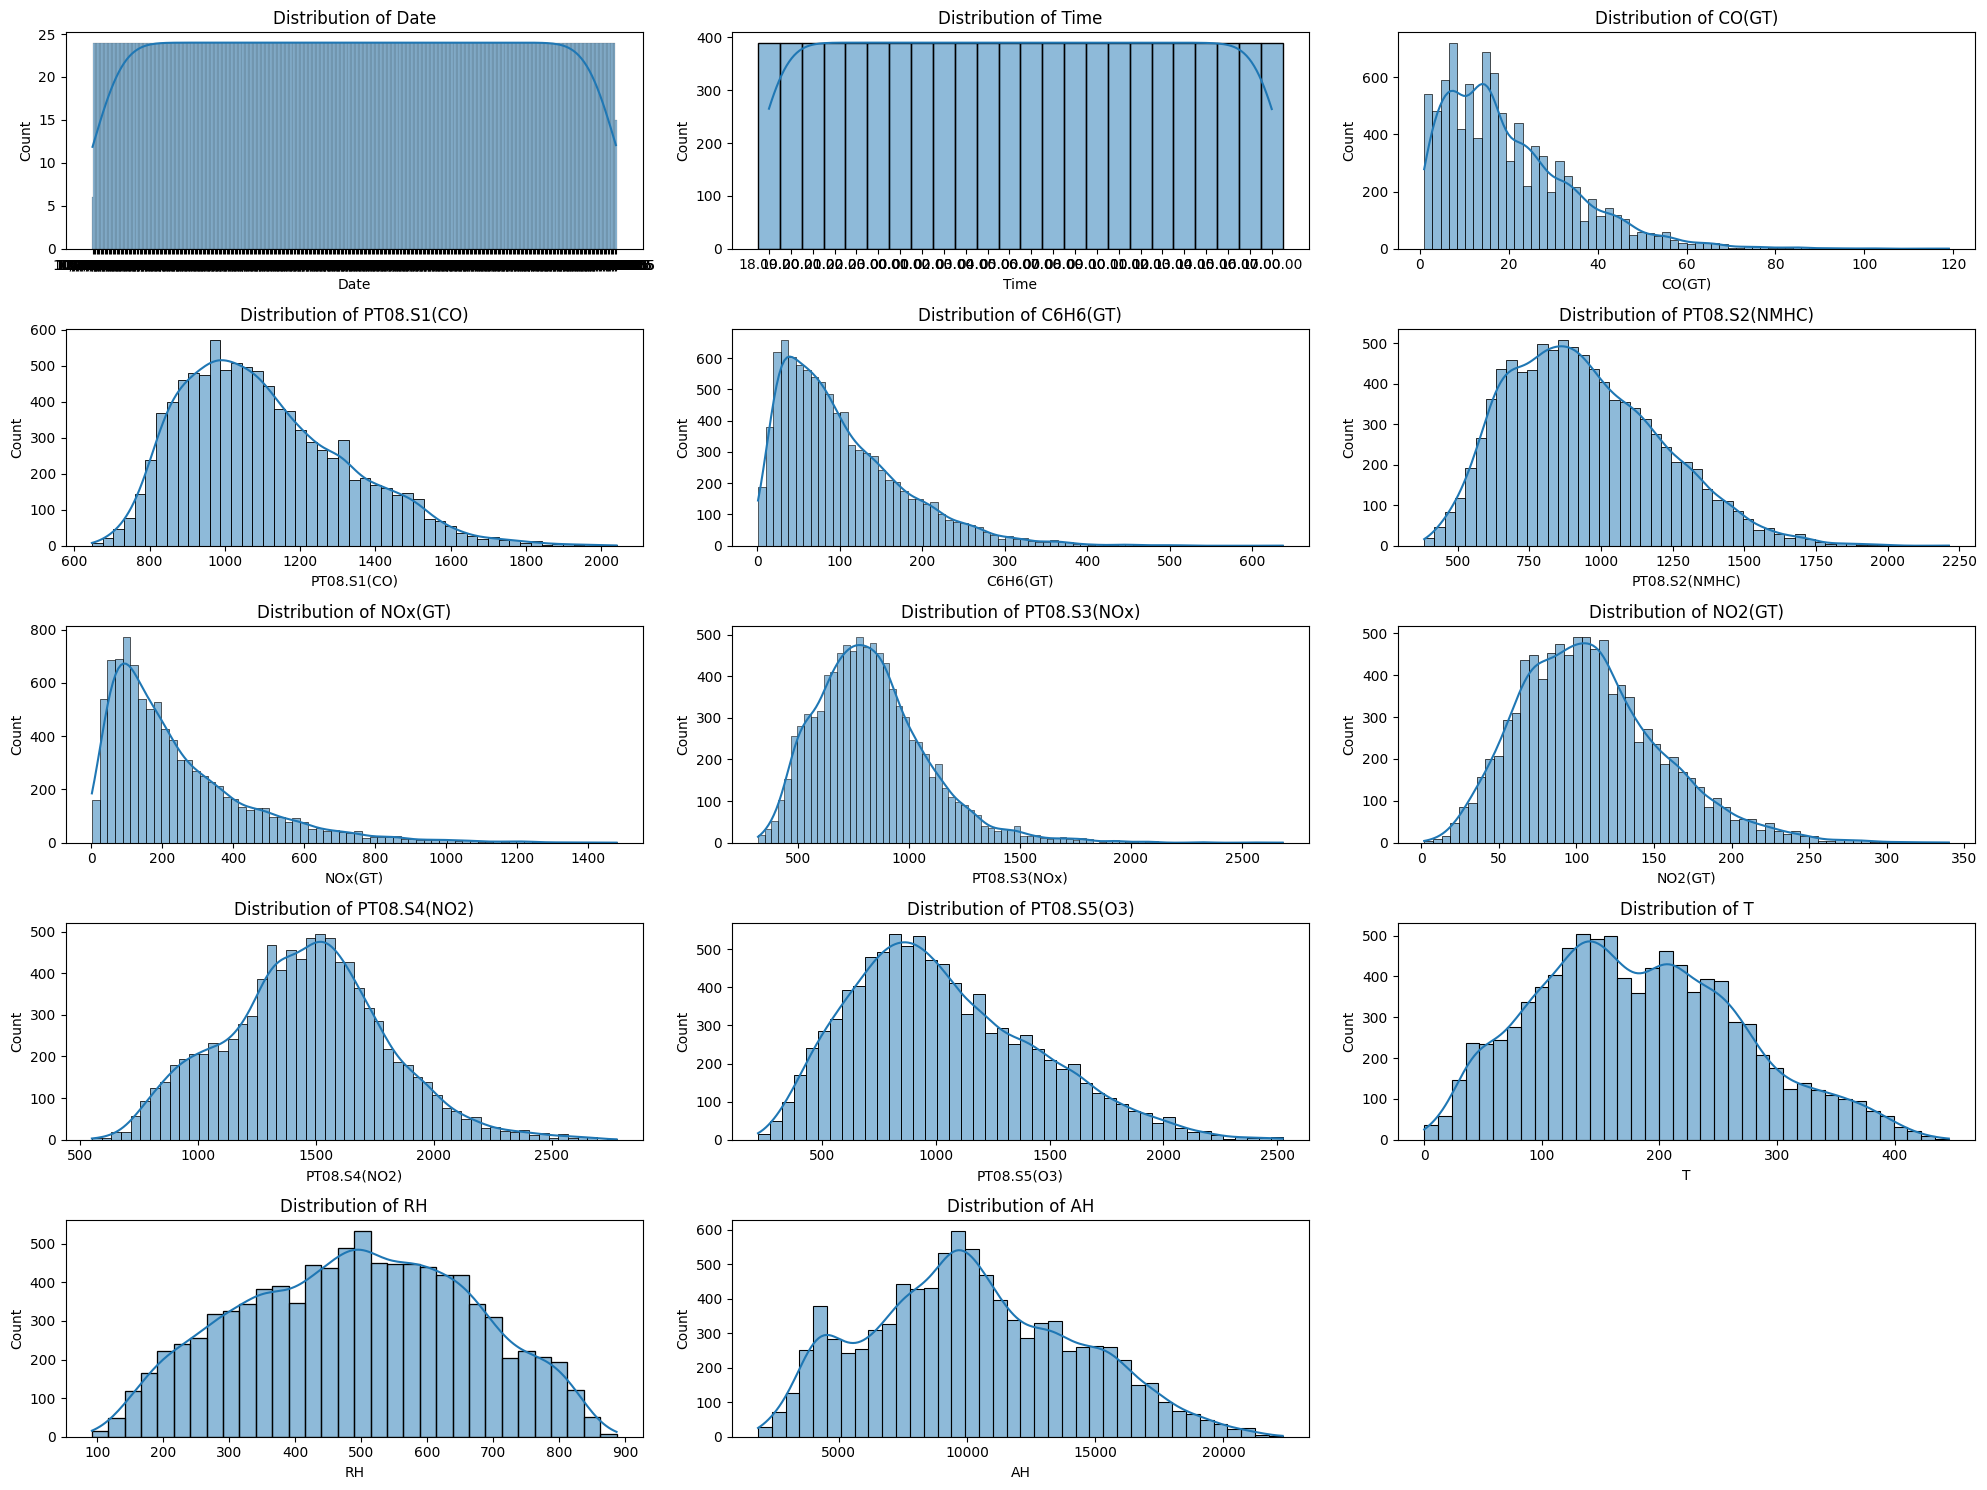

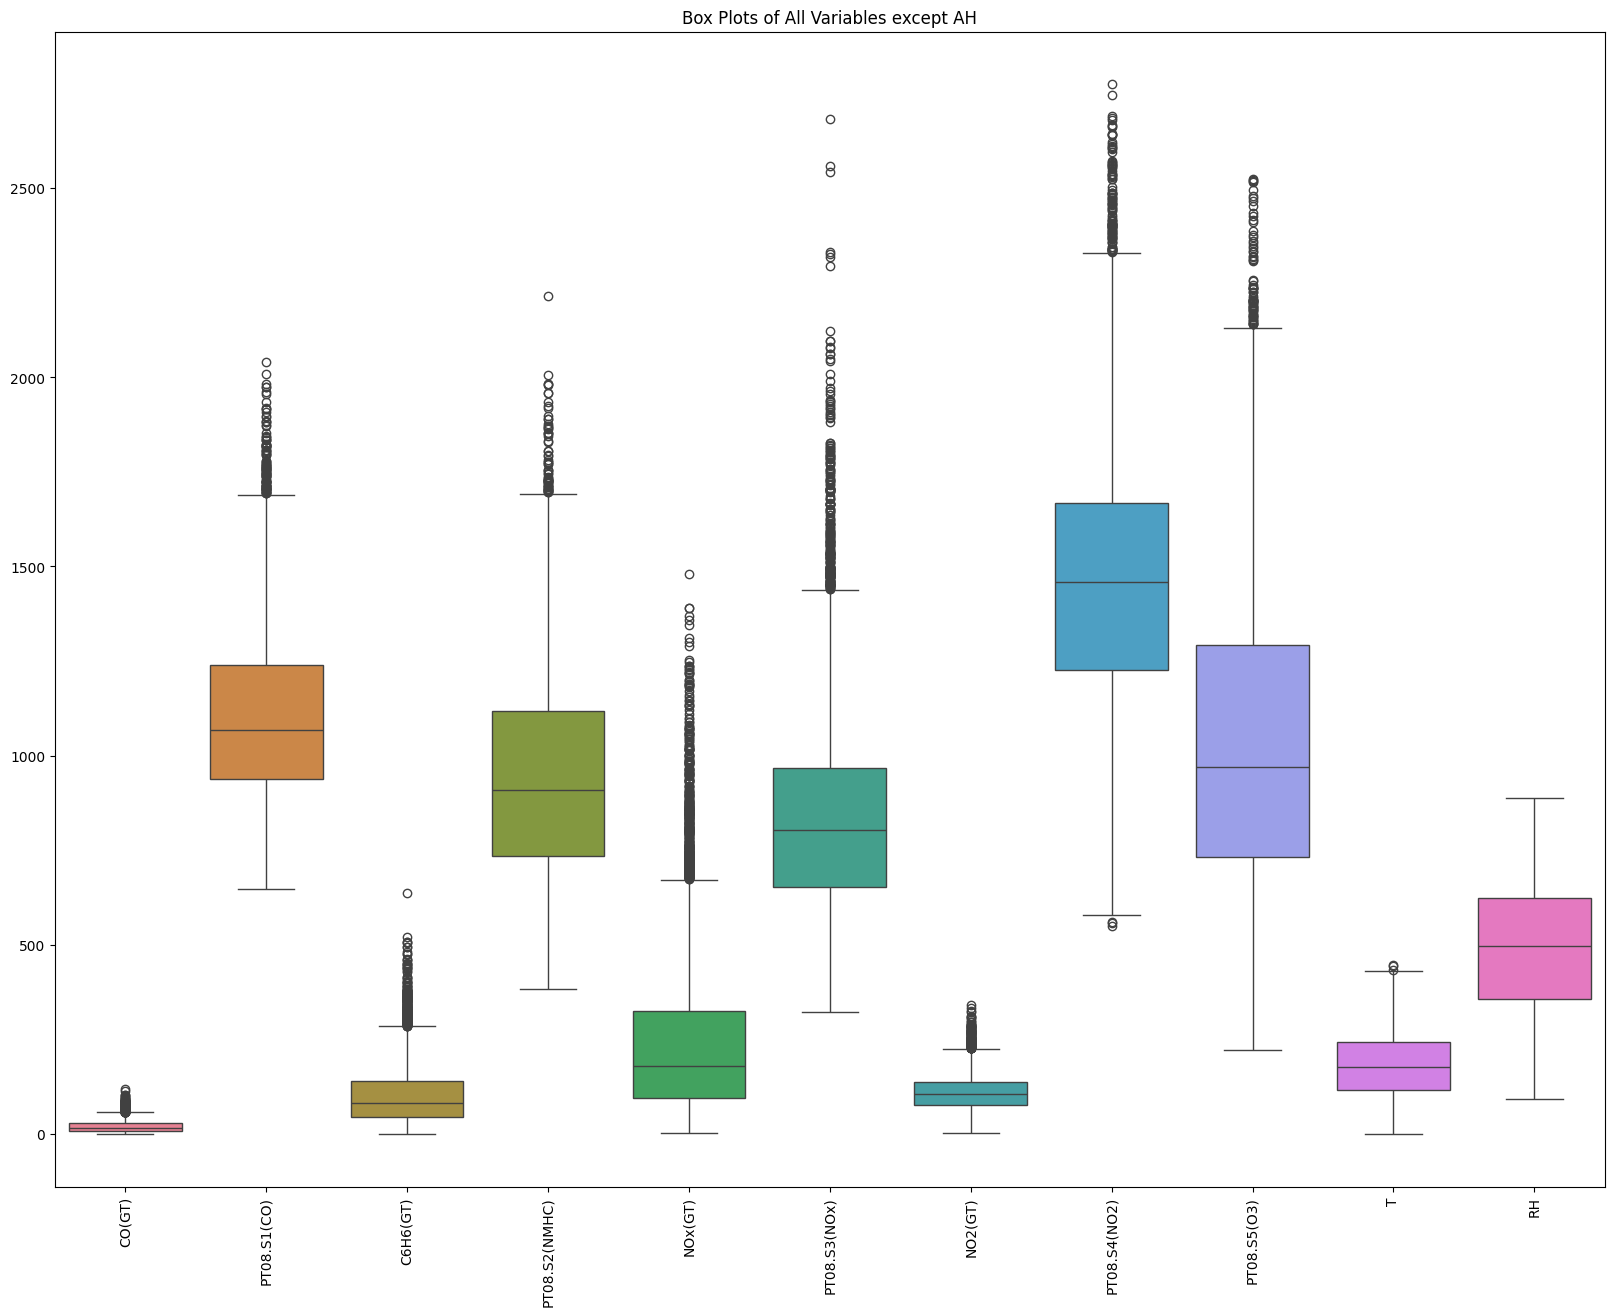

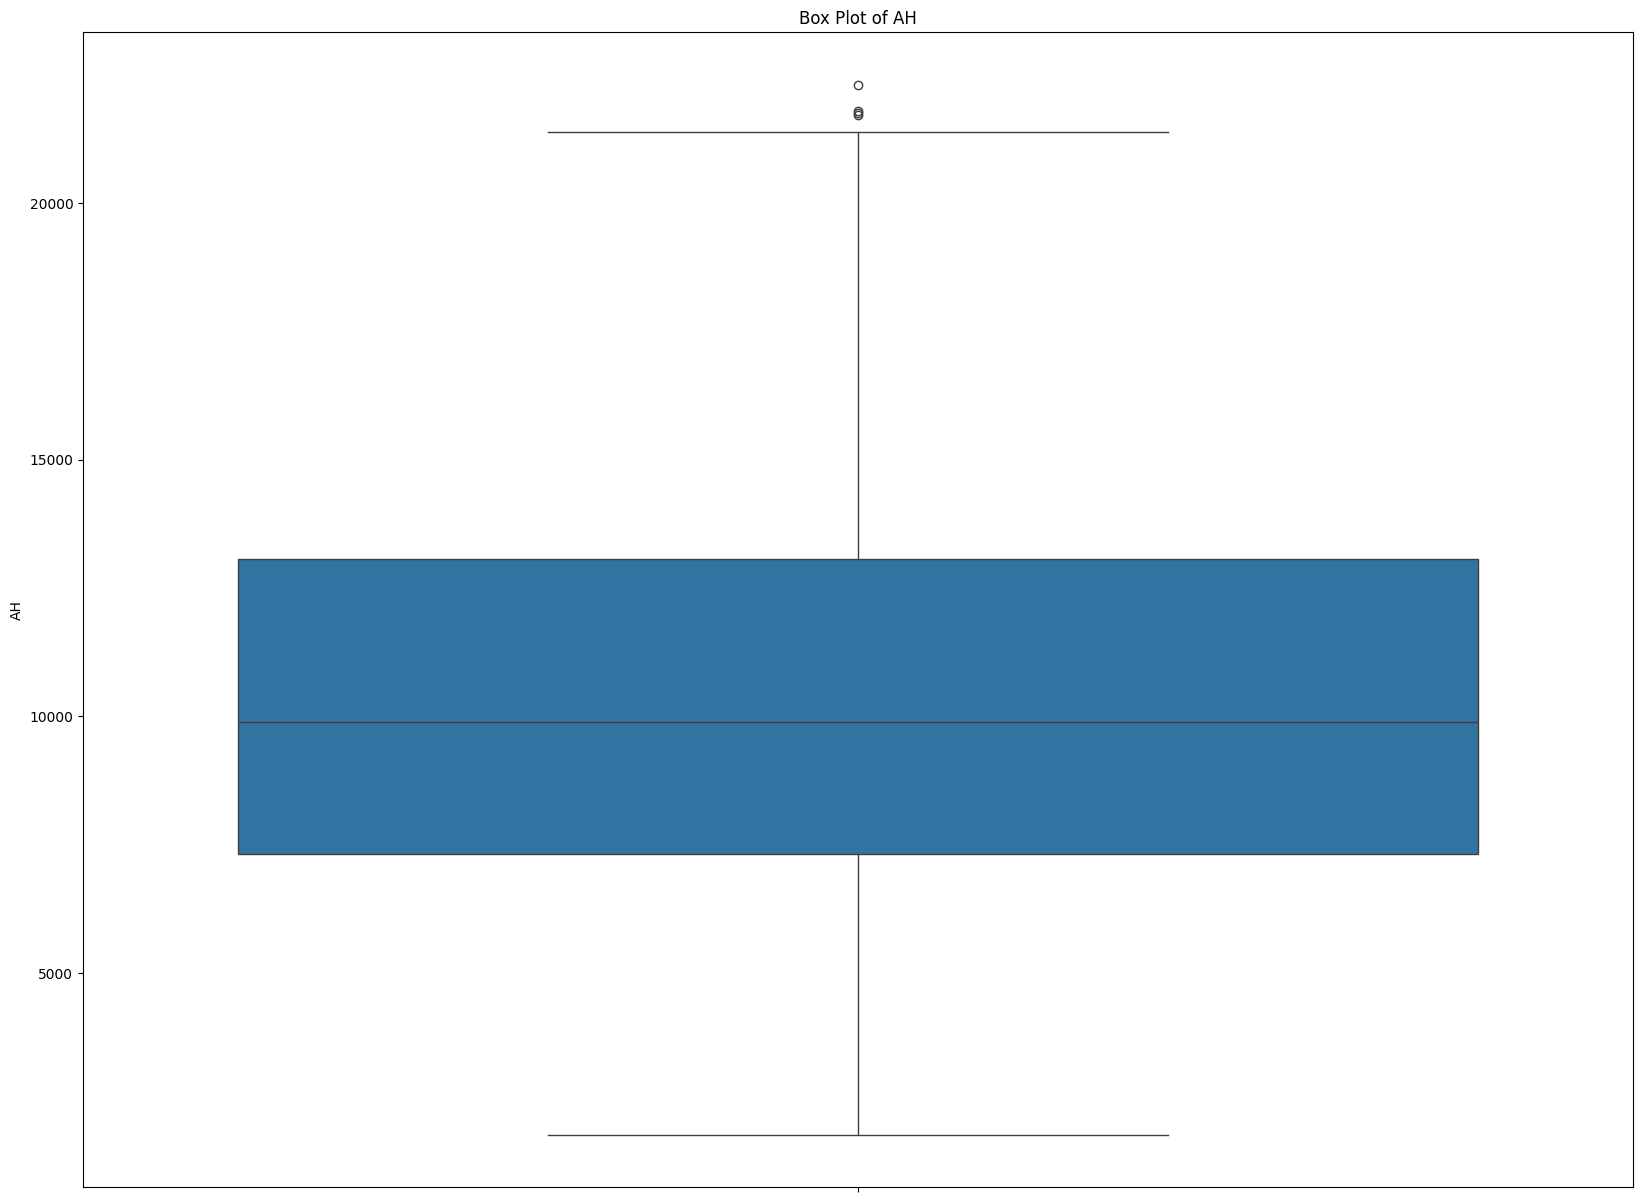

In [5]:
# Plot histograms and KDE plots
plt.figure(figsize=(20, 15))
for i, column in enumerate(air_df.columns):
    plt.subplot(5, 3, i + 1)
    sns.histplot(air_df[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.savefig('../reports/figures/univariate_histograms_kde.png')  # Save plot
plt.show()

# Plot box plots to detect outliers
plt.figure(figsize=(20, 15))
sns.boxplot(data=air_df.drop(columns='AH', axis=1))
plt.title('Box Plots of All Variables except AH')
plt.xticks(rotation=90)
plt.savefig('../reports/figures/boxplots_without_AH.png')  # Save plot
plt.show()

# ...for AH
plt.figure(figsize=(20, 15))
sns.boxplot(data=air_df['AH'])
plt.title('Box Plot of AH')
plt.savefig('../reports/figures/boxplot_AH.png')  # Save plot
plt.show()

### Bivariate Analysis

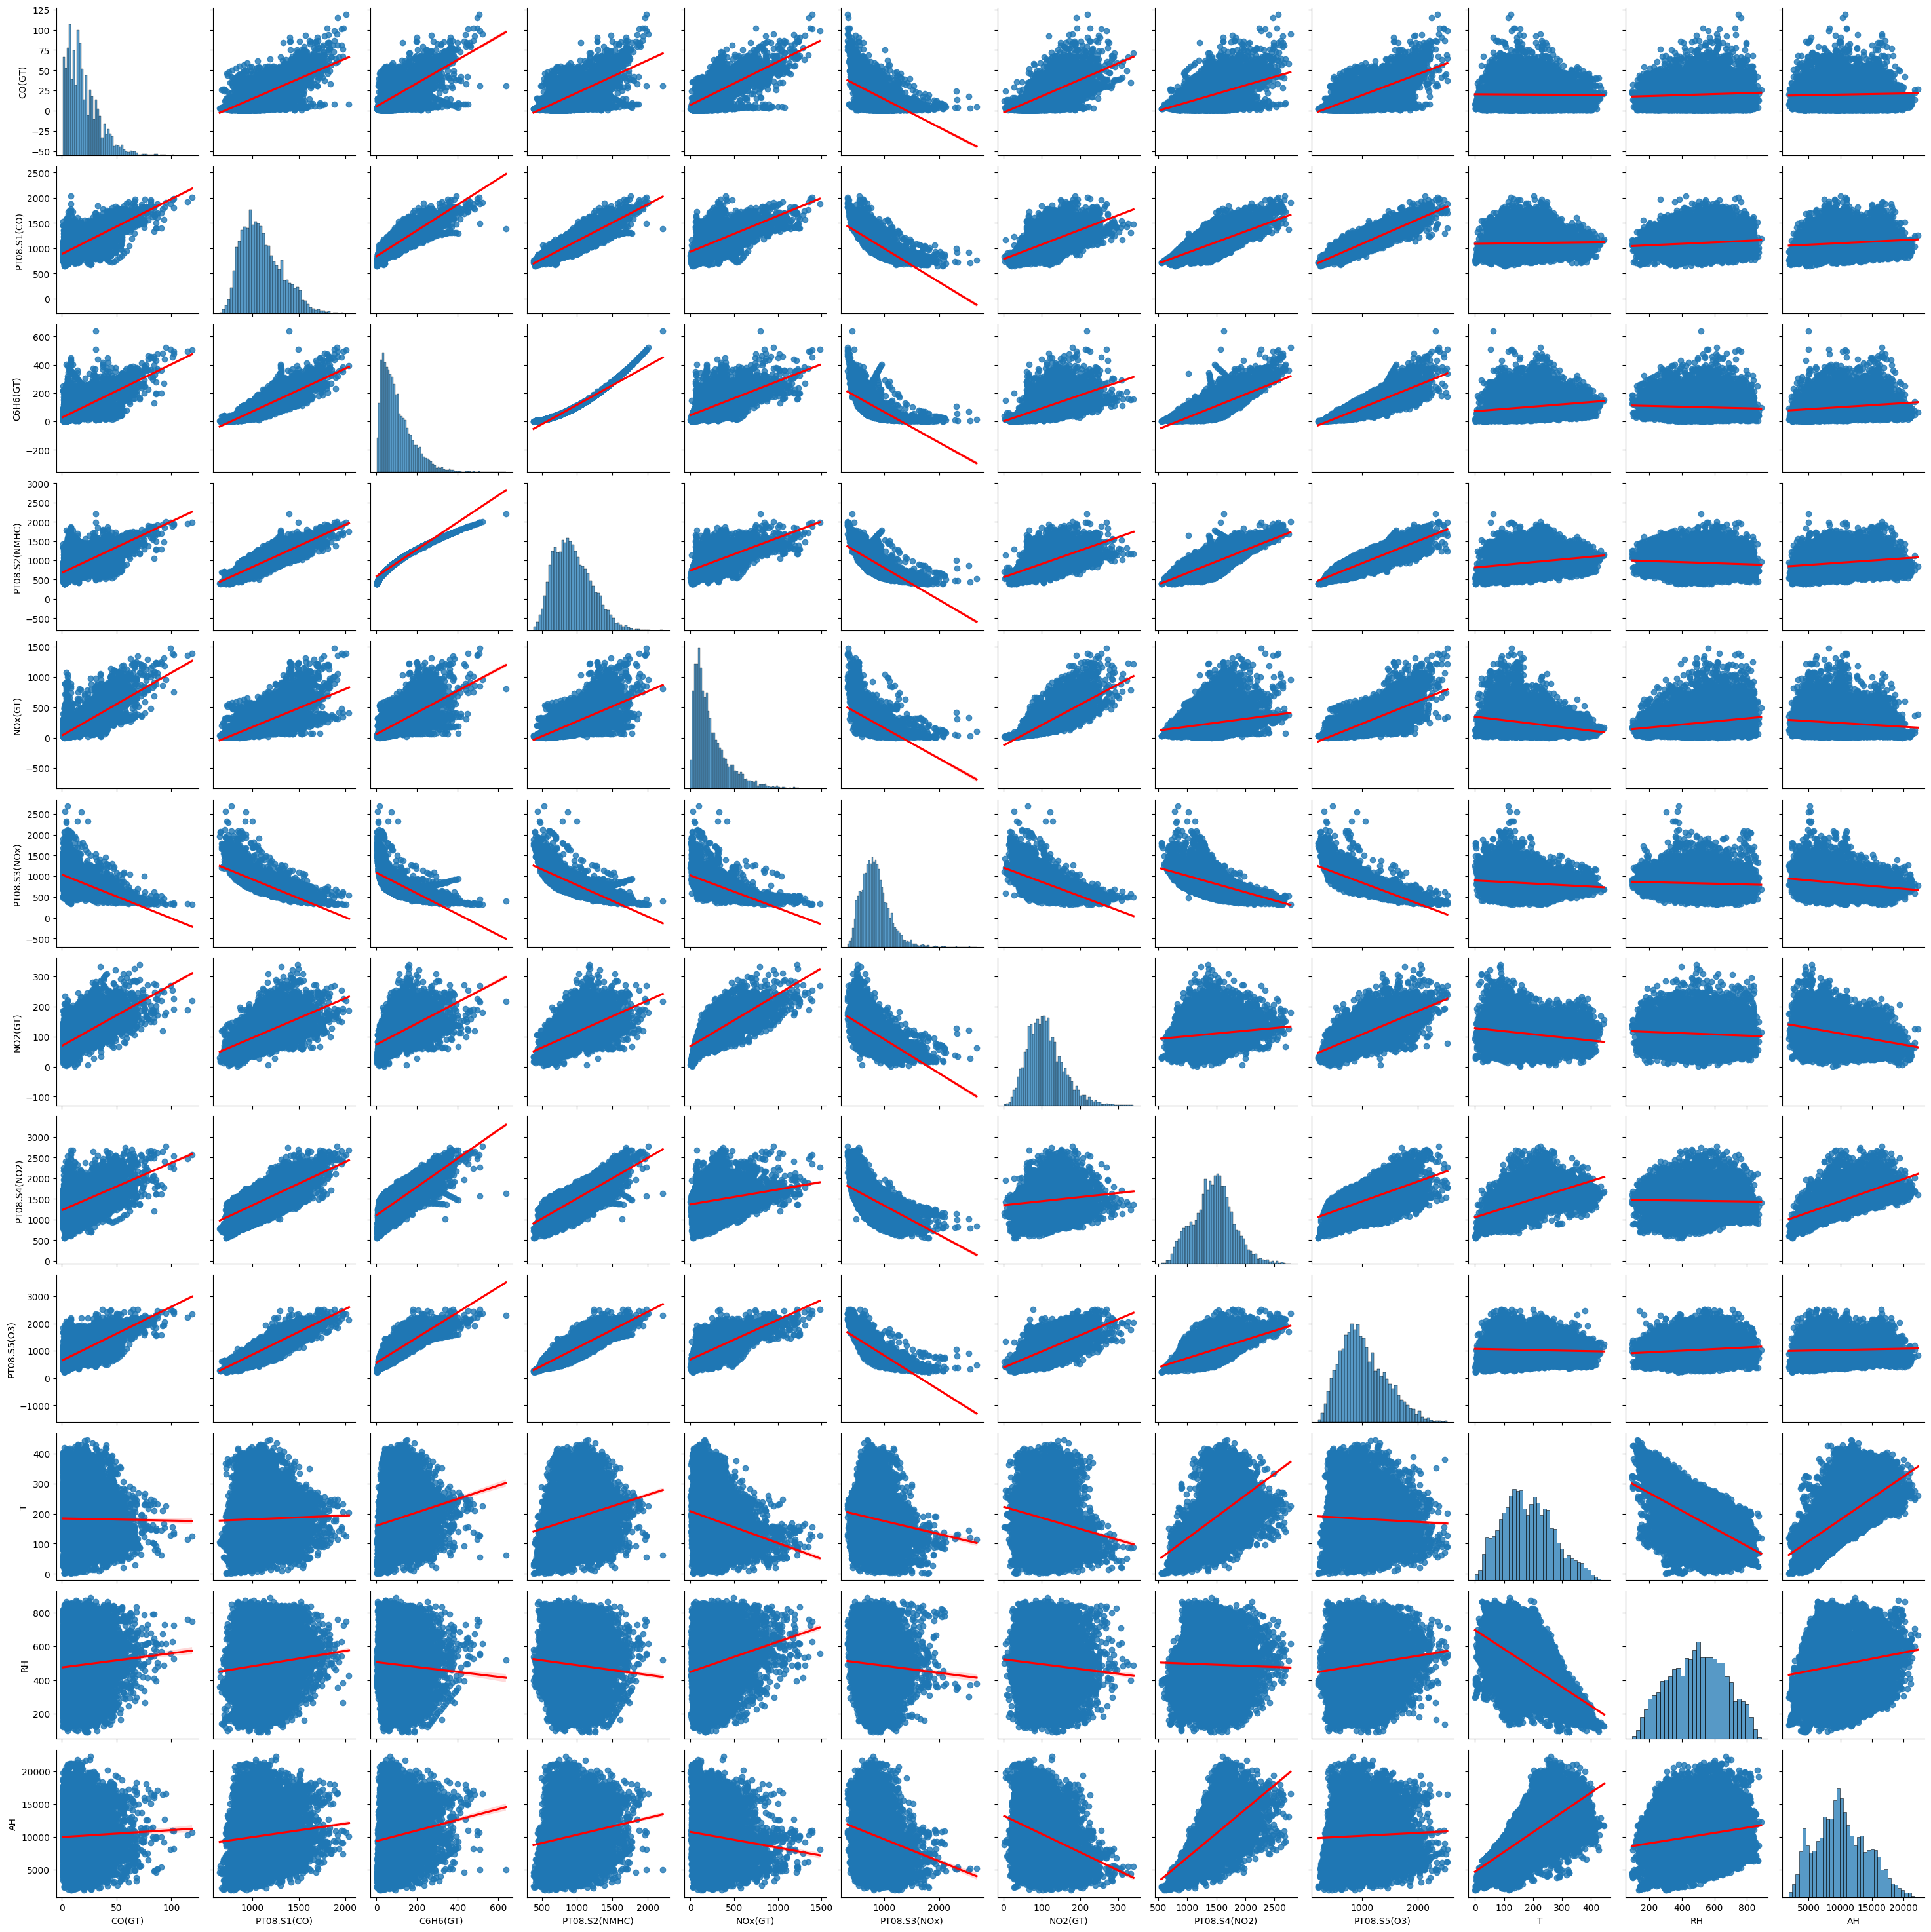

In [6]:
# Pairwise relationships
sns.pairplot(air_df, kind='reg', plot_kws={'line_kws': {'color': 'red'}})
plt.savefig('../reports/figures/pairwise_relationships.png')  # Save plot
plt.show()

### Multivariate Analysis

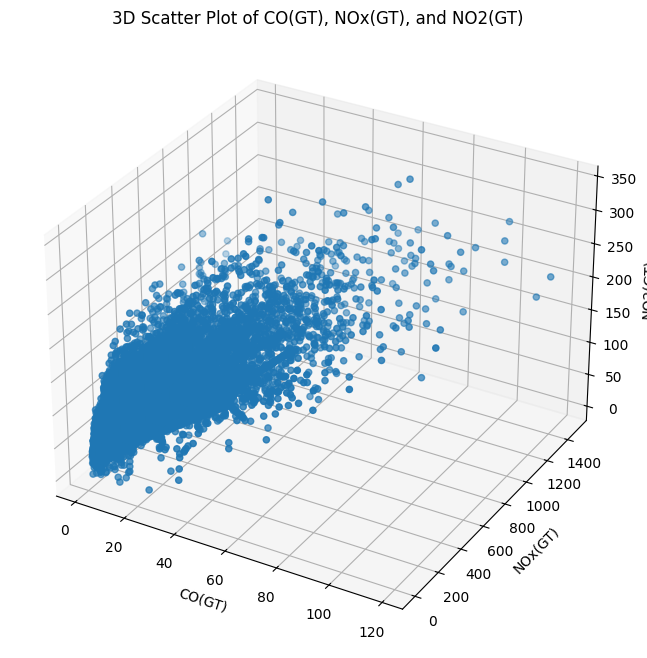

In [7]:
# 3D plot - example with CO(GT), NOx(GT), and NO2(GT)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(air_df['CO(GT)'], air_df['NOx(GT)'], air_df['NO2(GT)'])
ax.set_xlabel('CO(GT)')
ax.set_ylabel('NOx(GT)')
ax.set_zlabel('NO2(GT)')
plt.title('3D Scatter Plot of CO(GT), NOx(GT), and NO2(GT)')
plt.savefig('../reports/figures/3d_scatter_plot.png')  # Save plot
plt.show()

## TIme Series Analysis

### Date and Time Analysis

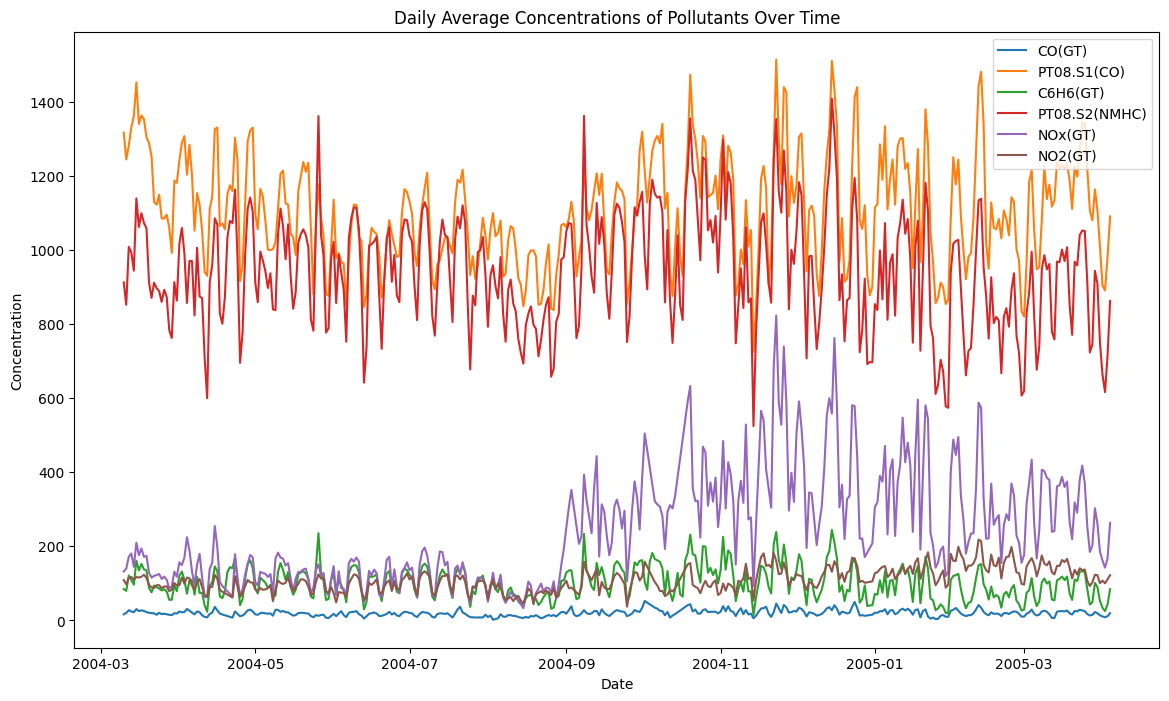

In [8]:
# Convert Date and Time to datetime
air_df['datetime'] = pd.to_datetime(air_df['Date'] + ' ' + air_df['Time'], format='%d/%m/%Y %H.%M.%S')

# Set datetime as index
air_df.set_index('datetime', inplace=True)

# Drop the original Date and Time columns
air_df.drop(['Date', 'Time'], axis=1, inplace=True)

# Plot time series for each pollutant
air_df_resampled = air_df.resample('D').mean()  # Resampling to daily averages

plt.figure(figsize=(14, 8))
for column in ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'NO2(GT)']:
    plt.plot(air_df_resampled.index, air_df_resampled[column], label=column)

plt.title('Daily Average Concentrations of Pollutants Over Time')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.legend()
plt.savefig('../reports/figures/daily_average_concentrations.png')  # Save plot
plt.show()

### Moving Averages

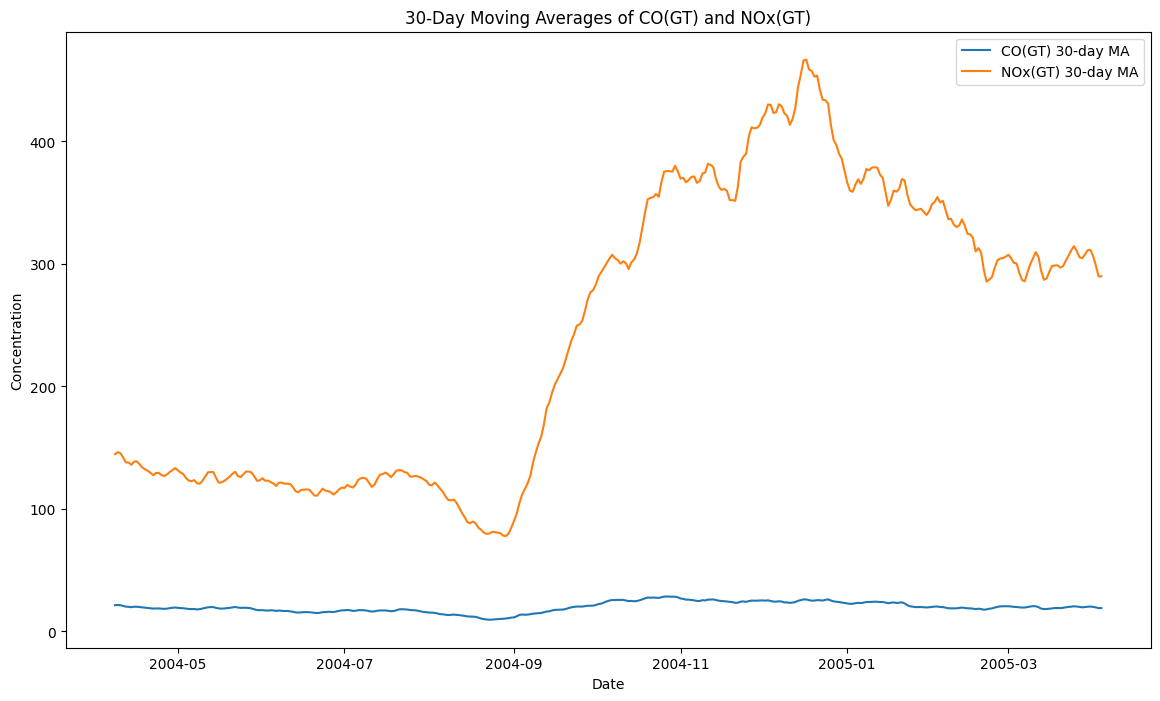

In [9]:
# Moving averages for smoothing
air_df_resampled['CO(GT)_MA'] = air_df_resampled['CO(GT)'].rolling(window=30).mean()
air_df_resampled['NOx(GT)_MA'] = air_df_resampled['NOx(GT)'].rolling(window=30).mean()

# Plot the moving averages
plt.figure(figsize=(14, 8))
plt.plot(air_df_resampled['CO(GT)_MA'], label='CO(GT) 30-day MA')
plt.plot(air_df_resampled['NOx(GT)_MA'], label='NOx(GT) 30-day MA')
plt.title('30-Day Moving Averages of CO(GT) and NOx(GT)')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.legend()
plt.savefig('../reports/figures/moving_averages.png')  # Save plot
plt.show()

### Seasonal Decomposition

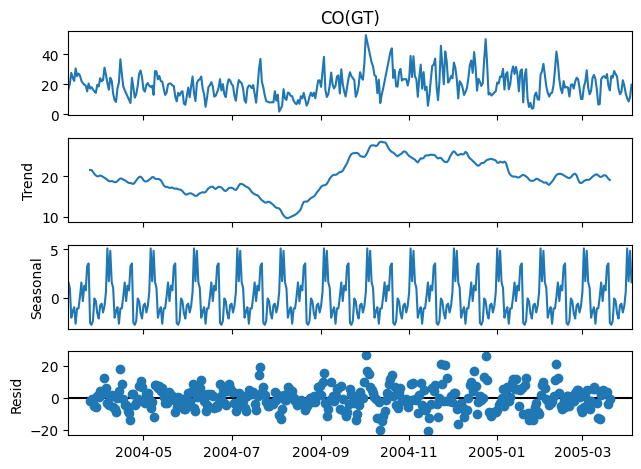

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(air_df_resampled['CO(GT)'].dropna(), model='additive', period=30)
result.plot()
plt.savefig('../reports/figures/seasonal_decomposition.png')  # Save plot
plt.show()

## Outlier Detection

In [11]:
from scipy.stats import zscore

# Calculate z-scores
z_scores = air_df.apply(zscore)

# Define outliers as data points with z-score > 3 or < -3
outliers = (z_scores.abs() > 3).sum()

outliers / air_df.shape[0]

CO(GT)           0.011863
PT08.S1(CO)      0.005985
C6H6(GT)         0.012718
PT08.S2(NMHC)    0.003954
NOx(GT)          0.017848
PT08.S3(NOx)     0.011863
NO2(GT)          0.007054
PT08.S4(NO2)     0.004595
PT08.S5(O3)      0.003099
T                0.000107
RH               0.000000
AH               0.000107
dtype: float64